# SQL-Based Extended Sentiment Analysis

Initial exploratory analysis suggests that the relationship between daily news sentiment and same-day market returns is relatively weak and noisy. This may occur because:

- market reactions may happen with delays,
- daily sentiment may contain substantial short-term noise,
- or sentiment may affect market volatility more than return direction.

To further investigate these possibilities, SQL is used to construct additional analytical variables and perform deeper sentiment analysis.


In [ ]:
try:
    %run news_sentiment_final.ipynb
except SystemExit:
    pass

/Users/sungyeonkim/anaconda3/envs/dsan5200/lib/python3.11/site-packages/nbformat/__init__.py:93: MissingIDFieldWarning: Code cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9372407 entries, 0 to 9372406
Data columns (total 4 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   rpa_date_utc           object 
 1   event_sentiment_score  float64
 2   topic                  object 
 3   headline               object 
dtypes: float64(1), object(3)
memory usage: 286.0+ MB


/var/folders/jb/_57y0k0x0wj5rxjpxc000yxc0000gn/T/ipykernel_31982/1091009651.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  sp500["daily_return"] = sp500["price"].pct_change()


SystemExit: 

/Users/sungyeonkim/anaconda3/envs/dsan5200/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [3]:
import sqlite3
import pandas as pd

# Create SQLite connection
conn = sqlite3.connect("sentiment_analysis.db")

# Export dataframe into SQLite
daily_merged.to_sql(
    "daily_market_sentiment",
    conn,
    if_exists="replace",
    index=False
)

print("SQL table successfully created.")


SQL table successfully created.


## Create Logical SQL Tables

The original merged dataset is separated into three logical SQL tables:

- sentiment table
- market return table
- news activity table

This structure allows SQL joins to be used more naturally in the subsequent analysis.


In [ ]:
# Query 1 — Create sentiment table

query_sentiment_table = '''
CREATE TABLE sentiment_table AS

SELECT
    trading_date,
    avg_sentiment,
    median_sentiment,
    avg_lm_score,
    avg_vader_score,
    positive_share,
    negative_share,
    neutral_share,
    sentiment_group

FROM daily_market_sentiment
'''

conn.execute(query_sentiment_table)

print("Sentiment table created.")


Sentiment table created.


In [ ]:
# Query 2 — Create market return table

query_market_table = '''
CREATE TABLE market_table AS

SELECT
    trading_date,
    price,
    daily_return,
    lag_return

FROM daily_market_sentiment
'''

conn.execute(query_market_table)

print("Market table created.")


Market table created.


In [ ]:
# Query 3 — Create news activity table

query_news_table = '''
CREATE TABLE news_table AS

SELECT
    trading_date,
    news_count,
    news_volume_group,
    high_news_volume

FROM daily_market_sentiment
'''

conn.execute(query_news_table)

print("News activity table created.")


News activity table created.


In [22]:
# Query 4 — Join sentiment and market returns

query_join_sentiment_market = '''
SELECT
    s.trading_date,
    s.avg_sentiment,
    m.daily_return

FROM sentiment_table s

JOIN market_table m
ON s.trading_date = m.trading_date
'''

join_sentiment_market_df = pd.read_sql(
    query_join_sentiment_market,
    conn
)

join_sentiment_market_df.head()


,trading_date,avg_sentiment,daily_return
0,2016-05-23 00:00:00,0.087376,NaN
1,2016-05-24 00:00:00,0.096409,0.013681
2,2016-05-25 00:00:00,0.100354,0.006975
3,2016-05-26 00:00:00,0.101852,-0.000210
4,2016-05-27 00:00:00,0.102329,0.004287


In [23]:
# Query 5 — Join sentiment and news activity

query_join_sentiment_news = '''
SELECT
    s.trading_date,
    s.avg_sentiment,
    n.news_count

FROM sentiment_table s

JOIN news_table n
ON s.trading_date = n.trading_date
'''

join_sentiment_news_df = pd.read_sql(
    query_join_sentiment_news,
    conn
)

join_sentiment_news_df.head()


,trading_date,avg_sentiment,news_count
0,2016-05-23 00:00:00,0.087376,62665
1,2016-05-24 00:00:00,0.096409,3530
2,2016-05-25 00:00:00,0.100354,3682
3,2016-05-26 00:00:00,0.101852,3821
4,2016-05-27 00:00:00,0.102329,2432


## Create Extended Analytical Table

The following SQL query combines sentiment, market, and news variables into a single analytical table. Additional variables are also constructed using SQL window functions.


In [ ]:
# Query 6 — Create extended analytical table

query_extended_analysis = '''
CREATE TABLE extended_sentiment_analysis AS

SELECT
    s.trading_date,
    s.avg_sentiment,
    s.avg_vader_score,
    s.avg_lm_score,
    s.positive_share,
    s.negative_share,

    n.news_count,
    n.news_volume_group,
    n.high_news_volume,

    m.daily_return,
    m.lag_return,

    LAG(s.avg_sentiment)
    OVER (ORDER BY s.trading_date) AS lag_sentiment,

    AVG(s.avg_sentiment)
    OVER (
        ORDER BY s.trading_date
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    ) AS rolling_sentiment_3d,

    ABS(m.daily_return) AS abs_return,

    RANK() OVER (
        ORDER BY ABS(m.daily_return) DESC
    ) AS volatility_rank

FROM sentiment_table s

JOIN news_table n
ON s.trading_date = n.trading_date

JOIN market_table m
ON s.trading_date = m.trading_date
'''

conn.execute(query_extended_analysis)

print("Extended analytical table created.")


Extended analytical table created.


In [8]:
# Query 7 — Sentiment group analysis

query_sentiment_group = '''
SELECT
    sentiment_group,

    COUNT(*) AS observations,
    AVG(daily_return) AS avg_return,
    AVG(abs_return) AS avg_abs_return

FROM extended_sentiment_analysis

GROUP BY sentiment_group
'''

sentiment_group_df = pd.read_sql(
    query_sentiment_group,
    conn
)

sentiment_group_df


,sentiment_group,observations,avg_return,avg_abs_return
0,negative,4,0.001167,0.002867
1,neutral,126,-0.004807,0.016528
2,positive,2348,0.000819,0.006842


In [9]:
# Query 8 — News volume group analysis

query_news_volume = '''
SELECT
    news_volume_group,

    COUNT(*) AS observations,
    AVG(abs_return) AS avg_volatility,
    AVG(daily_return) AS avg_return

FROM extended_sentiment_analysis

GROUP BY news_volume_group
'''

news_volume_df = pd.read_sql(
    query_news_volume,
    conn
)

news_volume_df


,news_volume_group,observations,avg_volatility,avg_return
0,high_news_volume,826,0.007810,0.000065
1,low_news_volume,828,0.006725,0.000772
2,medium_news_volume,824,0.007452,0.000763


In [26]:
# Query 9 — High volatility days (subquery)

query_high_volatility = '''
SELECT
    trading_date,
    news_count,
    abs_return

FROM extended_sentiment_analysis

WHERE abs_return >
(
    SELECT AVG(abs_return)
    FROM extended_sentiment_analysis
)

ORDER BY abs_return DESC
'''

high_volatility_df = pd.read_sql(
    query_high_volatility,
    conn
)

high_volatility_df.head()


,trading_date,news_count,abs_return
0,2020-03-16 00:00:00,4813,0.119841
1,2025-04-09 00:00:00,3863,0.095154
2,2020-03-12 00:00:00,4332,0.095113
3,2020-03-24 00:00:00,3875,0.093828
4,2020-03-13 00:00:00,2871,0.092871


In [27]:
# Query 10 — Extreme negative sentiment days (subquery)

query_negative_sentiment = '''
SELECT
    trading_date,
    lag_sentiment,
    daily_return

FROM extended_sentiment_analysis

WHERE lag_sentiment <
(
    SELECT AVG(lag_sentiment)
    FROM extended_sentiment_analysis
)

ORDER BY lag_sentiment ASC
'''

negative_sentiment_df = pd.read_sql(
    query_negative_sentiment,
    conn
)

negative_sentiment_df.head()


,trading_date,lag_sentiment,daily_return
0,2024-12-27 00:00:00,-0.080033,-0.011056
1,2017-01-24 00:00:00,-0.077250,0.006565
2,2018-01-23 00:00:00,-0.076277,0.002174
3,2025-12-29 00:00:00,-0.050372,-0.003492
4,2022-12-13 00:00:00,-0.048785,0.007290


In [28]:
# Query 11 — Volatility ranking

query_volatility_rank = '''
SELECT
    trading_date,
    abs_return,
    volatility_rank

FROM extended_sentiment_analysis

ORDER BY volatility_rank
'''

volatility_rank_df = pd.read_sql(
    query_volatility_rank,
    conn
)

volatility_rank_df.head()


,trading_date,abs_return,volatility_rank
0,2020-03-16 00:00:00,0.119841,1
1,2025-04-09 00:00:00,0.095154,2
2,2020-03-12 00:00:00,0.095113,3
3,2020-03-24 00:00:00,0.093828,4
4,2020-03-13 00:00:00,0.092871,5


In [29]:
# Query 12 — Sentiment quintile analysis

query_sentiment_quintile = '''
SELECT
    *,

    NTILE(5) OVER (
        ORDER BY avg_sentiment
    ) AS sentiment_quintile

FROM extended_sentiment_analysis
'''

sentiment_quintile_df = pd.read_sql(
    query_sentiment_quintile,
    conn
)

sentiment_quintile_df.head()


,trading_date,avg_sentiment,avg_vader_score,avg_lm_score,positive_share,negative_share,sentiment_group,news_count,news_volume_group,high_news_volume,daily_return,lag_return,lag_sentiment,rolling_sentiment_3d,abs_return,volatility_rank,sentiment_quintile
0,2024-12-26 00:00:00,-0.080033,0.041652,-0.216705,0.284717,0.363072,negative,1289,low_news_volume,0,-0.000406,-0.011056,0.066817,0.006575,0.000406,2333,1
1,2017-01-23 00:00:00,-0.077250,-0.067541,0.000747,0.248150,0.349046,negative,5134,high_news_volume,1,-0.002690,0.006565,-0.009702,-0.018621,0.002690,1681,1
2,2018-01-22 00:00:00,-0.076277,-0.043507,-0.035304,0.268592,0.361748,negative,5056,high_news_volume,1,0.008067,0.002174,-0.031172,-0.006508,0.008067,783,1
3,2025-12-26 00:00:00,-0.050372,0.073394,-0.185761,0.308120,0.350389,negative,899,low_news_volume,0,-0.000304,-0.003492,0.072903,0.037664,0.000304,2374,1
4,2022-12-12 00:00:00,-0.048785,-0.008787,-0.142072,0.331111,0.350953,neutral,6451,high_news_volume,1,0.014279,0.007290,0.122229,0.065375,0.014279,335,1


## Python Visualization of Extended Sentiment Analysis

After performing SQL-based analysis and feature construction, Python is used to visualize the relationships identified in the extended analysis.


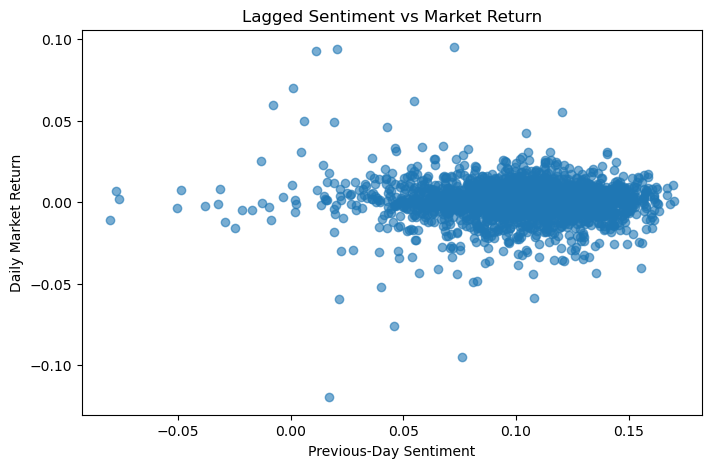

In [30]:
import matplotlib.pyplot as plt

# Chart 1 — Lagged sentiment vs market return

query_plot_1 = '''
SELECT
    lag_sentiment,
    daily_return
FROM extended_sentiment_analysis
WHERE lag_sentiment IS NOT NULL
'''

plot_df1 = pd.read_sql(query_plot_1, conn)

plt.figure(figsize=(8,5))

plt.scatter(
    plot_df1['lag_sentiment'],
    plot_df1['daily_return'],
    alpha=0.6
)

plt.title('Lagged Sentiment vs Market Return')
plt.xlabel('Previous-Day Sentiment')
plt.ylabel('Daily Market Return')

plt.show()


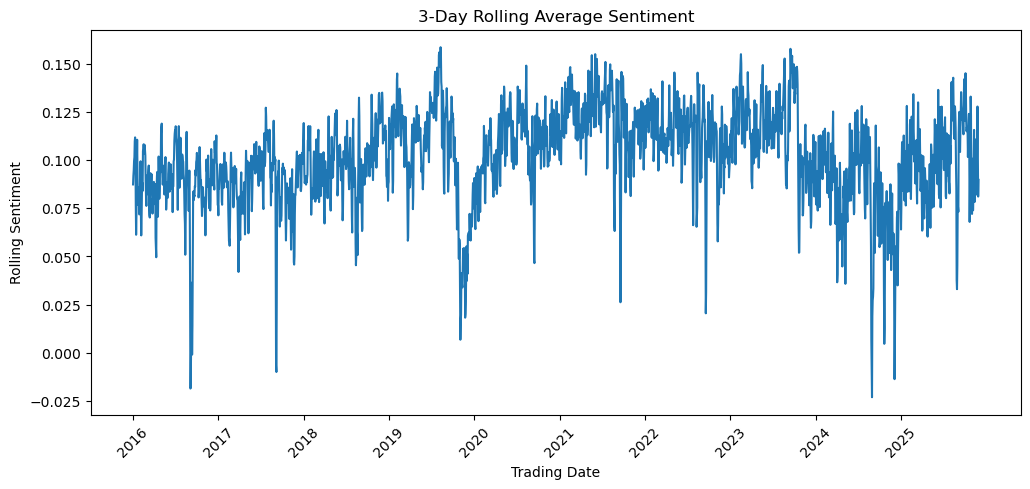

In [31]:
# Chart 2 — Rolling sentiment over time

query_plot_2 = '''
SELECT
    trading_date,
    rolling_sentiment_3d
FROM extended_sentiment_analysis
'''

plot_df2 = pd.read_sql(query_plot_2, conn)

plot_df2['year'] = pd.to_datetime(
    plot_df2['trading_date']
).dt.year

plt.figure(figsize=(12,5))

plt.plot(
    plot_df2['trading_date'],
    plot_df2['rolling_sentiment_3d']
)

plt.title('3-Day Rolling Average Sentiment')
plt.xlabel('Trading Date')
plt.ylabel('Rolling Sentiment')

plt.xticks(
    plot_df2.index[::250],
    plot_df2['year'][::250],
    rotation=45)

plt.show()


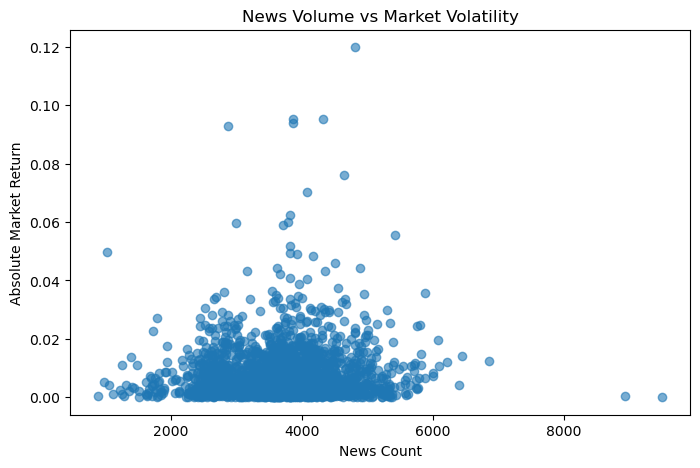

In [32]:
# Chart 3 — News volume vs market volatility

query_plot_3 = '''
SELECT
    news_count,
    abs_return
FROM extended_sentiment_analysis
'''

plot_df3 = pd.read_sql(query_plot_3, conn)

plt.figure(figsize=(8,5))

plt.scatter(
    plot_df3['news_count'],
    plot_df3['abs_return'],
    alpha=0.6
)

plt.title('News Volume vs Market Volatility')
plt.xlabel('News Count')
plt.ylabel('Absolute Market Return')

plt.show()
